# TP1: Sistema de Reconocimiento Facial - Desarrollo y Experimentación

Este notebook contiene el pipeline completo para el desarrollo del sistema de reconocimiento facial, desde la preparación del entorno hasta la evaluación de métricas.

---

## Equipo
- Alumno 1: Tapia Fabrizio
- Alumno 2: Caterina Martinez Dufour

## 1. Instalación de Dependencias
En esta sección se configuran las librerías necesarias para el procesamiento de imágenes y la ejecución de modelos de Deep Learning.
*   **Insightface:** Framework avanzado para análisis facial.
*   **OpenCV:** Manipulación de imágenes y video.
*   **ONNX Runtime (GPU):** Motor de inferencia optimizado.

In [2]:
!pip install insightface opencv-python onnxruntime-gpu
!pip install kagglehub

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl (12.9 MB)
   ---------------------------------------- 0.0/221.7 MB ? eta -:--:--
   - -------------------------------------- 6.0/221.7 MB 30.8 MB/s eta 0:00:07
   --- ------------------------------------ 17.8/221.7 MB 46.8 MB/s eta 0:00:05
   --- ------------------------------------ 21.0/221.7 MB 39.0 MB/s eta 0:00:06
   ----- ---------------------------------- 29.4/221.7 MB 35.8 MB/s eta 0:00:06
   ------ --------------------------------- 36.2/221.7 MB 35.4 MB/s eta 0:

  error: subprocess-exited-with-error
  
  × Building wheel for insightface (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [213 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-311\insightface
      copying insightface\__init__.py -> build\lib.win-amd64-cpython-311\insightface
      creating build\lib.win-amd64-cpython-311\insightface\app
      copying insightface\app\common.py -> build\lib.win-amd64-cpython-311\insightface\app
      copying insightface\app\face_analysis.py -> build\lib.win-amd64-cpython-311\insightface\app
      copying insightface\app\mask_renderer.py -> build\lib.win-amd64-cpython-311\insightface\app
      copying insightface\app\__init__.py -> build\lib.win-amd64-cpython-311\insightface\app
      creating build\lib.win-amd64-cpython-311\insightface\commands
      copying insightface\commands\insightface_cli.py -> build\lib.win-amd64-cpython-311\insightface\commands
  


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]




[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Carga del Dataset
Conexión con el almacenamiento (Google Drive o Local) y exploración inicial de las imágenes de entrenamiento y prueba. Se busca asegurar que las etiquetas y rutas sean consistentes.

In [14]:
import kagglehub
import shutil
from pathlib import Path

data_path = Path("data")
data_path.mkdir(parents=True, exist_ok=True)

downloaded_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

dest_path = data_path / "lfw-dataset"

if not dest_path.exists():
    print(f"Copiando dataset a {dest_path}...")
    shutil.copytree(downloaded_path, dest_path)

path = str(dest_path.absolute())
print("Path to dataset files:", path)

100%|██████████| 112M/112M [00:04<00:00, 24.5MB/s] 

Extracting files...


Path to dataset files: d:\FABRO\TUIA\5to Cuatri\Computer Vision\Nueva carpeta\data\lfw-dataset


### Vista previa del Dataset
Visualizamos algunas imágenes aleatorias para confirmar que la carga fue exitosa y verificar que los nombres de las carpetas correspondan a las identidades.

Total de imágenes encontradas: 13233


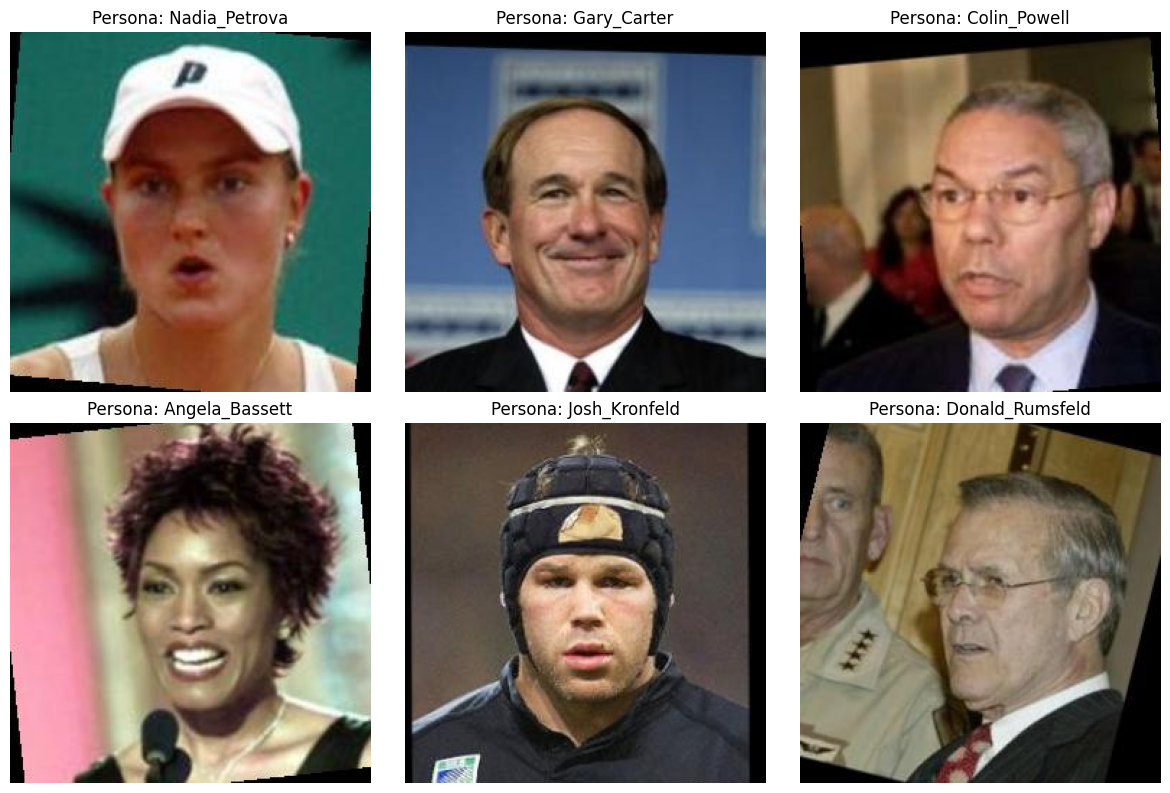

In [15]:
import matplotlib.pyplot as plt
from pathlib import Path
import random
from PIL import Image

base_path = Path(path)
all_images = list(base_path.glob('**/*.jpg'))

print(f"Total de imágenes encontradas: {len(all_images)}")

if all_images:
    sample_images = random.sample(all_images, min(6, len(all_images)))
    plt.figure(figsize=(12, 8))
    for i, img_path in enumerate(sample_images):
        plt.subplot(2, 3, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"Persona: {img_path.parent.name}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### Análisis Estadístico del Dataset
Para un sistema de reconocimiento facial, el balance del dataset es crítico. Analizaremos cuántas imágenes tenemos por persona y quiénes son las identidades más frecuentes. Esto nos ayudará a decidir qué umbrales utilizar y cómo seleccionar nuestro conjunto de prueba.

Análisis de Identidades:
- Total de personas únicas: 5749
- Promedio de fotos por persona: 2.30
- Persona con más fotos: George_W_Bush (530 fotos)
- Personas con una sola foto: 4069


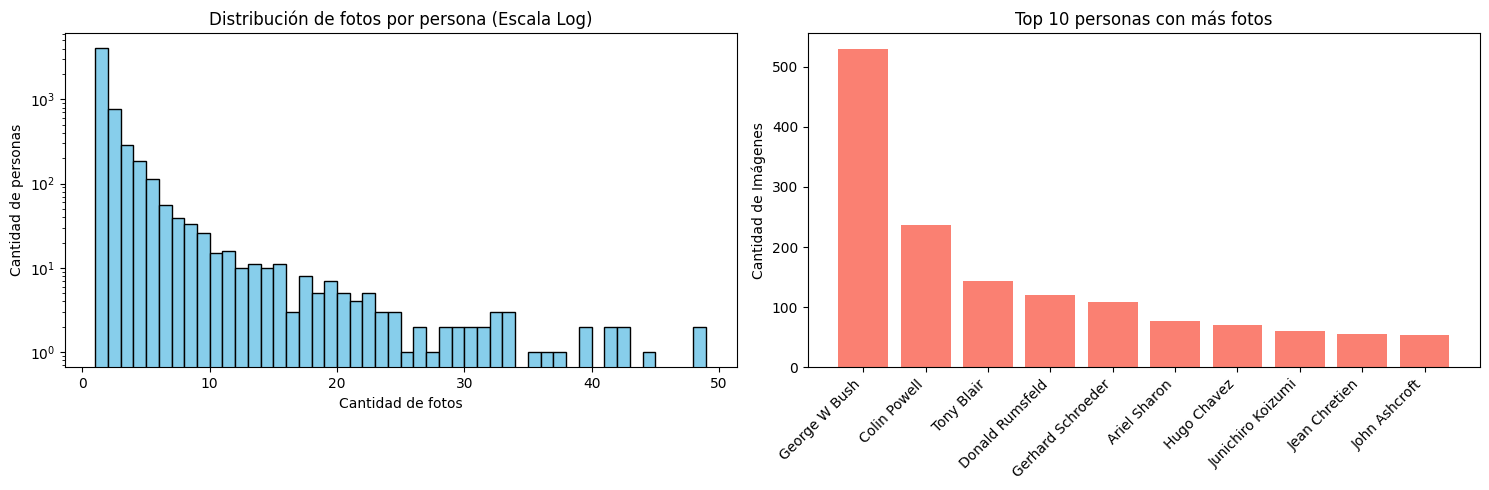

In [16]:
from collections import Counter

# Contar imágenes por persona (basado en el nombre de la carpeta padre)
identities = [p.parent.name for p in all_images]
counts = Counter(identities)

num_identities = len(counts)
img_per_person = list(counts.values())

print(f"Análisis de Identidades:")
print(f"- Total de personas únicas: {num_identities}")
print(f"- Promedio de fotos por persona: {len(all_images) / num_identities:.2f}")
print(f"- Persona con más fotos: {counts.most_common(1)[0][0]} ({counts.most_common(1)[0][1]} fotos)")
print(f"- Personas con una sola foto: {sum(1 for c in img_per_person if c == 1)}")

# Visualizar distribución y Top 10
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(img_per_person, bins=range(1, 50), color='skyblue', edgecolor='black')
plt.yscale('log') # Escala logarítmica para ver la diferencia entre los extremos
plt.title("Distribución de fotos por persona (Escala Log)")
plt.xlabel("Cantidad de fotos")
plt.ylabel("Cantidad de personas")

plt.subplot(1, 2, 2)
top_10 = counts.most_common(10)
plt.bar([x[0].replace('_', ' ') for x in top_10], [x[1] for x in top_10], color='salmon')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 personas con más fotos")
plt.ylabel("Cantidad de Imágenes")

plt.tight_layout()
plt.show()

### Segmentación del Dataset
Dividimos el dataset en tres grupos estratégicos:
1.  **Grupo A (Conocidos):** Identidades con $\ge 5$ imágenes. Constituyen nuestra base de datos de rostros conocidos.
2.  **Grupo B (Augmentation):** Identidades con 2 a 4 imágenes. Candidatos para aumentar su representación mediante técnicas sintéticas.
3.  **Grupo C (Desconocidos):** Identidades con una sola imagen. Actúan como el grupo de control para evaluar el rechazo de sujetos no registrados.

--- Análisis de Segmentación ---
Grupo A [Conocidos (>=5)]: 423 personas (7.4%)
Grupo B [Para Augmentation (2-4)]: 1257 personas (21.9%)
Grupo C [Desconocidos (1)]: 4069 personas (70.8%)

Total de registros en DataFrame: 13233


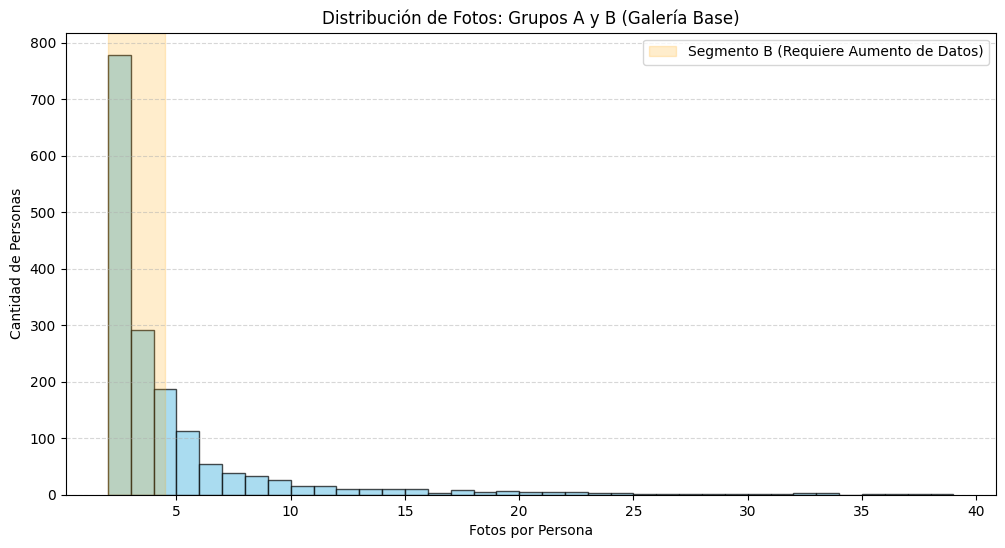

In [17]:
import pandas as pd

# 1. Definir criterios de segmentación
def get_segment(count):
    if count >= 5: return 'A'
    if count >= 2: return 'B'
    return 'C'

id_to_segment = {identity: get_segment(count) for identity, count in counts.items()}

# 2. Análisis Estadístico de los Grupos
total_ids = len(counts)
stats = pd.Series(id_to_segment.values()).value_counts().sort_index()

print("--- Análisis de Segmentación ---")
for seg, count in stats.items():
    label = {"A": "Conocidos (>=5)", "B": "Para Augmentation (2-4)", "C": "Desconocidos (1)"}[seg]
    print(f"Grupo {seg} [{label}]: {count} personas ({count/total_ids:.1%})")

# 3. Preparación del DataFrame de Rutas
df_dataset = pd.DataFrame([
    {'path': str(p), 'label': p.parent.name, 'segmento': id_to_segment[p.parent.name]}
    for p in all_images
])

print(f"\nTotal de registros en DataFrame: {len(df_dataset)}")

# 4. Visualización de Desbalance (Grupos A + B)
plt.figure(figsize=(12, 6))
ab_counts = [count for identity, count in counts.items() if id_to_segment[identity] in ['A', 'B']]

plt.hist(ab_counts, bins=range(2, 40), color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribución de Fotos: Grupos A y B (Galería Base)")
plt.xlabel("Fotos por Persona")
plt.ylabel("Cantidad de Personas")

# Resaltar el Segmento B
plt.axvspan(2, 4.5, color='orange', alpha=0.2, label='Segmento B (Requiere Aumento de Datos)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

df_dataset.to_csv('data/dataset_mapped.csv', index=False)

## 3. Benchmark de Detección: MTCNN vs RetinaFace
Comparativa de algoritmos de detección de rostros.
*   **Objetivo:** Evaluar precisión vs. velocidad y robustez ante variaciones de pose.
*   **Justificación:** Análisis de resultados para la elección del detector que se integrará en el `FaceService`.

## 4. Generación de Galería (Feature Store)
Implementación de la lógica para transformar imágenes de personas conocidas en vectores representativos (embeddings).
*   Detección y alineación.
*   Extracción de vectores con el modelo elegido.
*   Persistencia en un diccionario o estructura de datos para búsqueda rápida.

In [ ]:
def generate_gallery(path):
    # Recorrer carpetas, detectar rostros y extraer embeddings
    pass

## 5. Pruebas de Inferencia y Pipeline End-to-End
Desarrollo de la función principal de predicción.
1.  **Input:** Imagen sin procesar.
2.  **Pipeline:** Detección -> Alineación -> Extracción -> Identificación (Coseno/L2).
3.  **Output:** Visualización con Bounding Boxes y etiquetas (o "Unknown").

In [ ]:
def predict(image_path):
    # Implementar pipeline completo
    pass

## 6. Cálculo de Métricas y Evaluación
Validación del sistema utilizando un set de testeo.
*   **Matriz de Confusión:** Visualización de aciertos, Falsos Positivos y Falsos Negativos.
*   **Métricas Globales:** Accuracy, Precision y Recall para justificar la fiabilidad del modelo.

In [ ]:
# Generar matriz de confusión y reportar métricas